#  Decoding 기법
## Greedy · Beam Search · Sampling 비교 분석

---

## 왜 Decoding이 중요한가?

```
모델이 각 토큰의 확률 분포를 출력:
  P(나|<BOS>)         = ["나":0.6, "그":0.25, "우리":0.1, ...]
  P(학교|<BOS>,나)    = ["학교":0.5, "집":0.3, "음식":0.1, ...]
  P(간다|<BOS>,나,학교)= ["간다":0.7, "있다":0.2, ...]

→ 각 시점의 결정이 이후 전체 시퀀스에 영향!
→ 어떻게 최적의 시퀀스를 찾을 것인가? = Decoding 전략
```

## Decoding 방법 비교 요약

| 방법 | 설명 | 장점 | 단점 | 적합한 태스크 |
|------|------|------|------|---------------|
| **Greedy** | 매 시점 최고 확률 토큰 선택 | 빠름, 단순 | 지역 최적해 | 빠른 추론 |
| **Beam Search** | 상위 k개 후보를 동시 탐색 | 품질 좋음 | 느림, 메모리 | 번역, 요약 |
| **Top-k Sampling** | 상위 k개 중 확률적 선택 | 다양성 | 비일관성 | 창의적 생성 |
| **Top-p (Nucleus)** | 누적확률 p 이내에서 샘플링 | 균형 | 복잡함 | 대화, 스토리 |
| **Temperature** | 분포 날카롭기 조절 | 유연성 | 보조적 | 모든 태스크 |

---

## Greedy vs Beam Search 핵심 차이

```
토큰 확률 예시:
시점 1: A=0.6,  B=0.4
시점 2: A→C=0.3, A→D=0.7    |  B→C=0.9, B→D=0.1

Greedy (beam_size=1):
  → 시점1: A 선택 (0.6)  → 시점2: D 선택 (0.7)
  → 결과: A-D  (0.6 × 0.7 = 0.42)

Beam Search (beam_size=2):
  → 시점1: A(0.6), B(0.4) 모두 유지
  → 시점2: A-D(0.42), B-C(0.36), A-C(0.18), B-D(0.04)
  → 최종: A-D(0.42)  ← Greedy와 같지만...

시점 1: A=0.4,  B=0.6   ← 순서 바뀐 경우
시점 2: A→X=0.9,  B→Y=0.2

Greedy: B→Y = 0.6 × 0.2 = 0.12  ← 나쁜 결과!
Beam:   A→X = 0.4 × 0.9 = 0.36  ← Beam이 더 좋음!
```

In [40]:
# matplotlib 한글 깨짐 방지
# 한글 폰트 설치 및 설정
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import math
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42); random.seed(42); np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {device}')

✅ Device: cuda


## 1️⃣ 탐색 트리로 이해하는 Greedy vs Beam Search

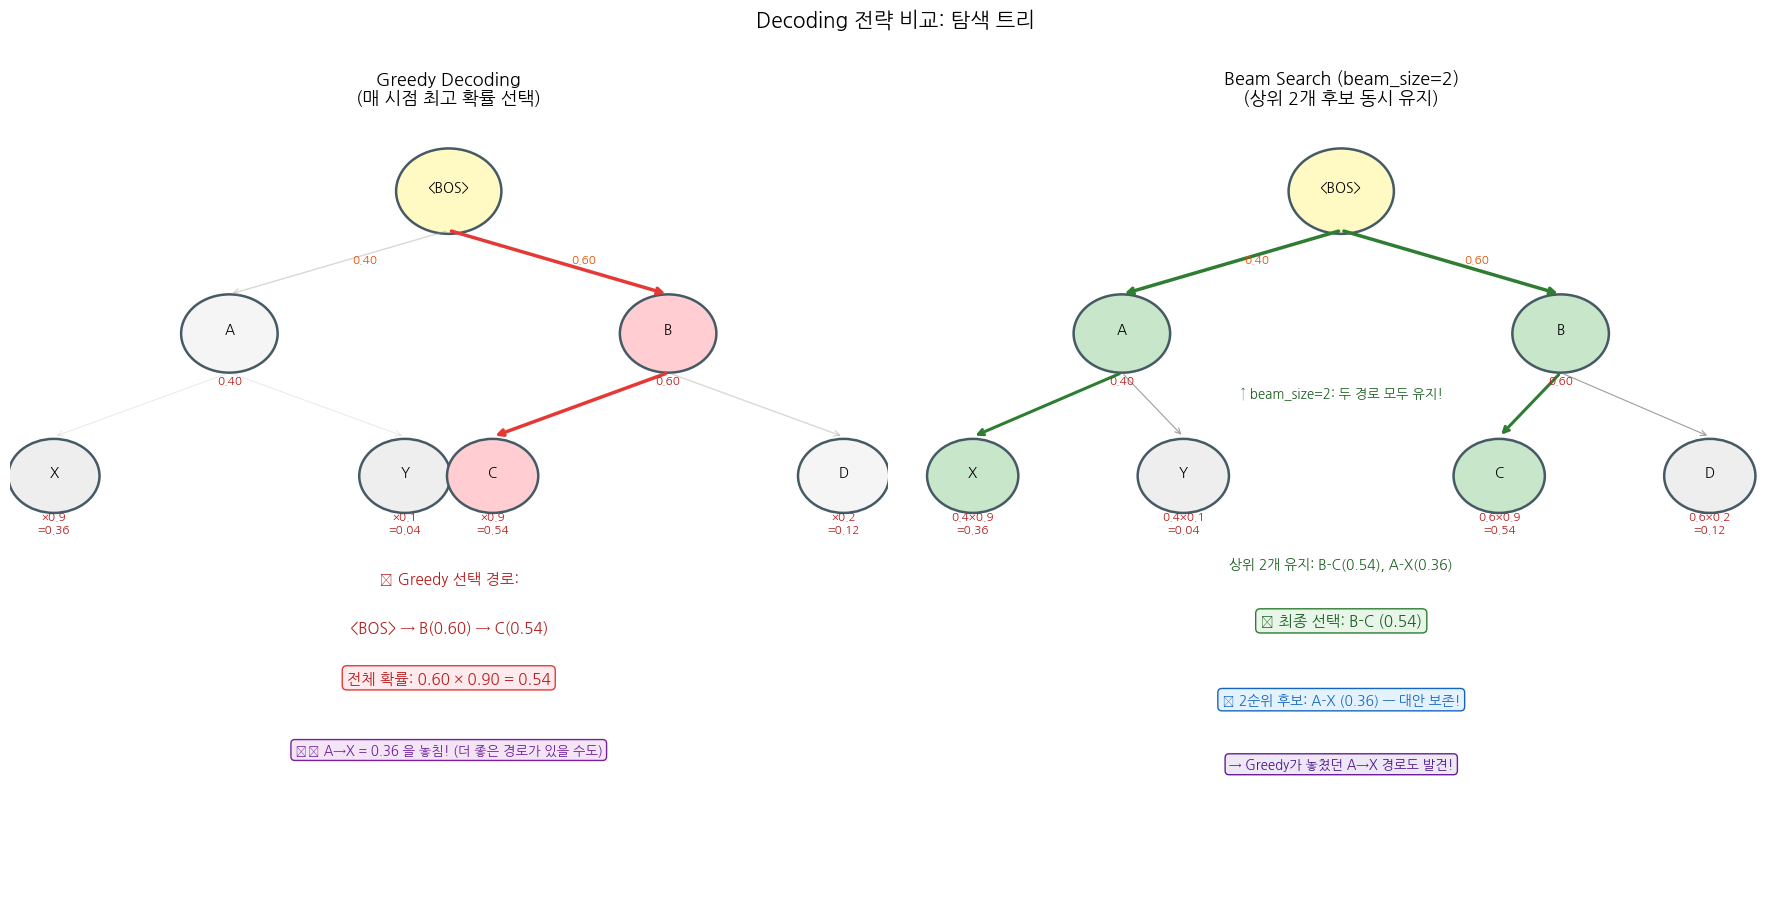

In [42]:
# ─── 탐색 트리 시각화 ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

def draw_node(ax, x, y, label, score='', color='#E3F2FD', size=0.55, fontsize=10):
    circ = plt.Circle((x, y), size, color=color, ec='#455A64', lw=1.8, zorder=3)
    ax.add_patch(circ)
    ax.text(x, y+0.05, label, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', zorder=4)
    if score:
        ax.text(x, y-0.65, score, ha='center', va='center', fontsize=8.5,
                color='#B71C1C', zorder=4, fontweight='bold')

def draw_edge(ax, x1, y1, x2, y2, label='', color='#546E7A', lw=1.5, alpha=1.0, chosen=False):
    ax.annotate('', xy=(x2, y2+0.55), xytext=(x1, y1-0.55),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw+chosen, alpha=alpha))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=8.5, color='#E65100', fontweight='bold')

# ── Greedy Decoding ───────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(-1, 10); ax.axis('off')
ax.set_title('Greedy Decoding\n(매 시점 최고 확률 선택)', fontsize=13, fontweight='bold', pad=12)

# 레이어 1
draw_node(ax, 5, 9, '<BOS>', color='#FFF9C4', size=0.6, fontsize=10)

# 레이어 2 (A=0.4 chosen in Greedy이 아닌 B=0.6이 선택)
nodes_l2 = [(2.5, 7, 'A', '0.40'), (7.5, 7, 'B', '0.60')]
for x,y,l,s in nodes_l2:
    chosen = (l == 'B')
    col = '#FFCDD2' if chosen else '#F5F5F5'
    draw_node(ax, x, y, l, s, color=col)
    ec = '#E53935' if chosen else '#9E9E9E'
    draw_edge(ax, 5, 9, x, y, label=s, color=ec, lw=2.5 if chosen else 1.0,
              alpha=1.0 if chosen else 0.4)

# 레이어 3 - B의 자식만 표시 (Greedy)
nodes_l3_B = [(5.5, 5, 'C', '×0.9\n=0.54'), (9.5, 5, 'D', '×0.2\n=0.12')]
nodes_l3_A = [(0.5, 5, 'X', '×0.9\n=0.36'), (4.5, 5, 'Y', '×0.1\n=0.04')]
for x,y,l,s in nodes_l3_A:
    draw_node(ax, x, y, l, s, color='#EEEEEE', size=0.52)
    draw_edge(ax, 2.5, 7, x, y, color='#BDBDBD', lw=0.8, alpha=0.3)
for x,y,l,s in nodes_l3_B:
    chosen = (l == 'C')
    col = '#FFCDD2' if chosen else '#F5F5F5'
    draw_node(ax, x, y, l, s, color=col, size=0.52)
    draw_edge(ax, 7.5, 7, x, y, color='#E53935' if chosen else '#9E9E9E',
              lw=2.5 if chosen else 1.0, alpha=1.0 if chosen else 0.4)

# 선택된 경로 강조
ax.text(5, 3.5, '✅ Greedy 선택 경로:', ha='center', fontsize=11, fontweight='bold', color='#B71C1C')
ax.text(5, 2.8, '<BOS> → B(0.60) → C(0.54)', ha='center', fontsize=11, color='#B71C1C')
ax.text(5, 2.1, '전체 확률: 0.60 × 0.90 = 0.54', ha='center', fontsize=11,
        fontweight='bold', color='#B71C1C',
        bbox=dict(boxstyle='round', fc='#FFEBEE', ec='#E53935'))
ax.text(5, 1.1, '⚠️ A→X = 0.36 을 놓침! (더 좋은 경로가 있을 수도)', ha='center',
        fontsize=9.5, color='#6A1B9A',
        bbox=dict(boxstyle='round', fc='#F3E5F5', ec='#7B1FA2'))

# ── Beam Search (beam_size=2) ─────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(-1, 10); ax.axis('off')
ax.set_title('Beam Search (beam_size=2)\n(상위 2개 후보 동시 유지)', fontsize=13, fontweight='bold', pad=12)

draw_node(ax, 5, 9, '<BOS>', color='#FFF9C4', size=0.6)

for x,y,l,s in [(2.5,7,'A','0.40'),(7.5,7,'B','0.60')]:
    draw_node(ax, x, y, l, s, color='#C8E6C9')
    draw_edge(ax, 5, 9, x, y, label=s, color='#2E7D32', lw=2.5)

ax.text(5, 6.1, '↑ beam_size=2: 두 경로 모두 유지!', ha='center',
        fontsize=9.5, color='#1B5E20', fontweight='bold')

# A의 자식
for x,y,l,s in [(0.8,5,'X','0.4×0.9\n=0.36'),(3.2,5,'Y','0.4×0.1\n=0.04')]:
    col = '#C8E6C9' if l=='X' else '#EEEEEE'
    draw_node(ax, x, y, l, s, color=col, size=0.52)
    draw_edge(ax, 2.5, 7, x, y, color='#2E7D32' if l=='X' else '#9E9E9E',
              lw=2.2 if l=='X' else 0.8)
# B의 자식
for x,y,l,s in [(6.8,5,'C','0.6×0.9\n=0.54'),(9.2,5,'D','0.6×0.2\n=0.12')]:
    col = '#C8E6C9' if l=='C' else '#EEEEEE'
    draw_node(ax, x, y, l, s, color=col, size=0.52)
    draw_edge(ax, 7.5, 7, x, y, color='#2E7D32' if l=='C' else '#9E9E9E',
              lw=2.2 if l=='C' else 0.8)

ax.text(5, 3.7, '상위 2개 유지: B-C(0.54), A-X(0.36)', ha='center',
        fontsize=10, color='#1B5E20', fontweight='bold')
ax.text(5, 2.9, '✅ 최종 선택: B-C (0.54)', ha='center', fontsize=11,
        fontweight='bold', color='#1B5E20',
        bbox=dict(boxstyle='round', fc='#E8F5E9', ec='#2E7D32'))
ax.text(5, 1.8, '✅ 2순위 후보: A-X (0.36) — 대안 보존!', ha='center',
        fontsize=10, color='#1565C0',
        bbox=dict(boxstyle='round', fc='#E3F2FD', ec='#1565C0'))
ax.text(5, 0.9, '→ Greedy가 놓쳤던 A→X 경로도 발견!', ha='center',
        fontsize=9.5, color='#4A148C',
        bbox=dict(boxstyle='round', fc='#EDE7F6', ec='#6A1B9A'))

plt.suptitle('Decoding 전략 비교: 탐색 트리', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('decoding_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 2️⃣ 모의 언어 모델 — 확률 분포 생성기

In [43]:
# 디코딩 실험용 어휘 및 간단한 언어 모델
VOCAB = ['<PAD>','<UNK>','<BOS>','<EOS>',
         '나','는','학교','에','간다','책','읽','는다','음악','듣',
         '밥','먹','집','에서','잔다','공부','한다','운동','뛴다','논다']
V2I = {w:i for i,w in enumerate(VOCAB)}
I2V = {i:w for w,i in V2I.items()}
VOCAB_SIZE = len(VOCAB)
PAD, UNK, BOS, EOS = 0, 1, 2, 3


class ToyLM(nn.Module):
    """
    디코딩 기법 실험용 간단한 언어 모델
    LSTM + FC → 다음 토큰 확률 분포
    """
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc        = nn.Linear(hidden_dim, vocab_size)
        self.hidden_dim= hidden_dim

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(out)
        return logits, hidden

    def get_next_probs(self, token_id, hidden=None, temperature=1.0):
        """단일 토큰 입력 → 다음 토큰 확률 분포"""
        x = torch.tensor([[token_id]]).to(device) # 입력 텐서를 올바른 장치로 이동.
        logits, hidden = self(x, hidden)
        logits = logits[0, -1] / temperature
        probs  = F.softmax(logits, dim=-1)
        return probs, hidden


# 간단 학습 데이터 (토큰 시퀀스)
SENTENCES = [
    '나 는 학교 에 간다',
    '나 는 책 읽 는다',
    '나 는 음악 듣 는다',
    '나 는 밥 먹 는다',
    '나 는 집 에서 잔다',
    '나 는 공부 한다',
    '나 는 운동 한다',
]

lm = ToyLM().to(device)
opt = torch.optim.Adam(lm.parameters(), lr=5e-3)
crit= nn.CrossEntropyLoss(ignore_index=PAD)

print('언어 모델 학습 중...')
for epoch in range(1, 301):
    lm.train()
    for sent in SENTENCES:
        ids = [BOS] + [V2I.get(w, UNK) for w in sent.split()] + [EOS]
        x_t = torch.tensor([ids[:-1]]).to(device)
        y_t = torch.tensor([ids[1:]]).to(device)
        opt.zero_grad()
        logits, _ = lm(x_t)
        loss = crit(logits.view(-1, VOCAB_SIZE), y_t.view(-1))
        loss.backward(); opt.step()
    if epoch % 100 == 0:
        print(f'  Epoch {epoch}: loss={loss.item():.4f}')
print('✅ 학습 완료')

언어 모델 학습 중...
  Epoch 100: loss=0.3714
  Epoch 200: loss=0.3702
  Epoch 300: loss=0.3697
✅ 학습 완료


## 3️⃣ Greedy Decoding 구현

```python
Greedy Decoding:
    for t in range(max_len):
        probs = model.next_probs(current_token)
        next_token = argmax(probs)   ← 매 시점 최고 확률만 선택
        if next_token == EOS: break
```

In [44]:
@torch.no_grad()
def greedy_decode(model, start_token=BOS, max_len=15, temperature=1.0, verbose=True):
    """
    Greedy Decoding: 매 시점 argmax
    """
    model.eval()
    token  = start_token
    hidden = None
    result = []
    prob_history = []
    total_log_prob = 0.0

    global device # 해당 범위 내에서 장치를 사용할 수 있는지 확인.

    for step in range(max_len):
        probs, hidden = model.get_next_probs(token, hidden, temperature)
        next_id = probs.argmax().item()   # ★ Greedy: 최고 확률 선택
        max_prob = probs[next_id].item()
        total_log_prob += math.log(max_prob + 1e-10)
        prob_history.append((I2V[next_id], max_prob, probs.detach().cpu().numpy()))

        if verbose:
            # 상위 3개 확률 표시
            top3 = probs.topk(3)
            top3_str = ' | '.join(f'{I2V[i.item()]}:{p.item():.3f}'
                                   for p,i in zip(top3.values, top3.indices))
            marker = '✅' if next_id != EOS else '🔚'
            print(f'  Step {step+1}: {marker} [{I2V[next_id]}] ({max_prob:.4f}) | Top3: [{top3_str}]')

        if next_id == EOS:
            break
        result.append(I2V[next_id])
        token = next_id

    perplexity = math.exp(-total_log_prob / max(len(result), 1))
    return result, total_log_prob, perplexity, prob_history


print('[Greedy Decoding — 시작 토큰: <BOS>]')

result_greedy, log_prob, ppl, prob_hist = greedy_decode(lm, verbose=True)
print(f'\n결과: {" ".join(result_greedy)}')
print(f'로그 확률: {log_prob:.4f}')
print(f'Perplexity: {ppl:.2f}')

[Greedy Decoding — 시작 토큰: <BOS>]
  Step 1: ✅ [나] (1.0000) | Top3: [나:1.000 | 듣:0.000 | 는:0.000]
  Step 2: ✅ [는] (1.0000) | Top3: [는:1.000 | 나:0.000 | 간다:0.000]
  Step 3: ✅ [공부] (0.1636) | Top3: [공부:0.164 | 운동:0.161 | 집:0.137]
  Step 4: ✅ [한다] (0.9998) | Top3: [한다:1.000 | 듣:0.000 | 먹:0.000]
  Step 5: 🔚 [<EOS>] (1.0000) | Top3: [<EOS>:1.000 | 는다:0.000 | 한다:0.000]

결과: 나 는 공부 한다
로그 확률: -1.8104
Perplexity: 1.57


## 4️⃣ Beam Search Decoding 구현

```
Beam Search (beam_size=k):
  
  초기: [(BOS, score=0, hidden=None)]
  
  매 스텝:
    각 빔에 대해 vocab_size개의 다음 토큰 후보 확장
    전체 k × vocab_size 후보 중 상위 k개만 유지
    
  종료: EOS 토큰 생성 or max_len 도달
  
  최종: 완성된 빔 중 가장 높은 점수 선택
         (길이 페널티 적용 가능)
```

In [45]:
@torch.no_grad()
def beam_search_decode(model, beam_size=3, max_len=15, temperature=1.0,
                        length_penalty=0.6, verbose=True):
    """
    Beam Search Decoding

    beam_size:      유지할 후보 수 (k)
    length_penalty: 긴 시퀀스에 대한 페널티 (0=없음, 1=선형)
                   score / (len)^α  — Google NMT 방식
    """
    model.eval()

    # Beam: (log_prob, sequence, hidden_state)
    beams = [(0.0, [BOS], None)]
    completed = []

    for step in range(max_len):
        all_candidates = []

        if verbose and step < 5:
            print(f'\n  Step {step+1} — 현재 빔 {len(beams)}개 확장:')

        for log_prob, seq, hidden in beams:
            last_token = seq[-1]
            if last_token == EOS:
                completed.append((log_prob, seq, hidden))
                continue

            # 다음 토큰 확률 계산
            probs, new_hidden = model.get_next_probs(last_token, hidden, temperature)
            log_probs = torch.log(probs + 1e-10)  # 로그 확률

            # 상위 beam_size개 후보 추가
            top_k = log_probs.topk(beam_size)
            for lp, tid in zip(top_k.values, top_k.indices):
                tid = tid.item()
                new_log_prob = log_prob + lp.item()
                new_seq      = seq + [tid]
                all_candidates.append((new_log_prob, new_seq, new_hidden))

        if not all_candidates:
            break

        # 길이 페널티 적용 후 상위 k개 선택
        def length_penalized_score(item):
            lp, seq, _ = item
            L = max(len(seq) - 1, 1)  # BOS 제외
            return lp / (L ** length_penalty)

        all_candidates.sort(key=length_penalized_score, reverse=True)
        beams = all_candidates[:beam_size]

        if verbose and step < 5:
            print(f'    상위 {beam_size}개 후보:')
            for rank, (lp, seq, _) in enumerate(beams):
                seq_words = [I2V.get(t, '?') for t in seq[1:]]
                print(f'      [{rank+1}] {" ".join(seq_words)}  (log_prob={lp:.4f})')

    completed.extend(beams)
    completed.sort(key=length_penalized_score, reverse=True)
    best = completed[0]

    result_tokens = [I2V.get(t, '?') for t in best[1][1:]
                     if t not in (BOS, EOS, PAD)]
    return result_tokens, best[0], completed


print('[Beam Search Decoding — beam_size=3]\n')
result_beam, best_score, all_beams = beam_search_decode(lm, beam_size=3, verbose=True)

print(f'\n[모든 완성된 빔 결과]')
for rank, (lp, seq, _) in enumerate(all_beams[:5]):
    words = [I2V.get(t,'?') for t in seq[1:] if t not in (EOS, PAD)]
    print(f'  {rank+1}위: "{" ".join(words)}"  (log_prob={lp:.4f})')

print(f'\n✅ 최종 선택: "{" ".join(result_beam)}"')

[Beam Search Decoding — beam_size=3]


  Step 1 — 현재 빔 1개 확장:
    상위 3개 후보:
      [1] 나  (log_prob=-0.0000)
      [2] 듣  (log_prob=-11.3292)
      [3] 는  (log_prob=-11.4889)

  Step 2 — 현재 빔 3개 확장:
    상위 3개 후보:
      [1] 나 는  (log_prob=-0.0001)
      [2] 듣 는  (log_prob=-11.3745)
      [3] 나 나  (log_prob=-11.6956)

  Step 3 — 현재 빔 3개 확장:
    상위 3개 후보:
      [1] 나 는 공부  (log_prob=-1.8102)
      [2] 나 는 운동  (log_prob=-1.8234)
      [3] 나 는 집  (log_prob=-1.9859)

  Step 4 — 현재 빔 3개 확장:
    상위 3개 후보:
      [1] 나 는 공부 한다  (log_prob=-1.8103)
      [2] 나 는 운동 한다  (log_prob=-1.8236)
      [3] 나 는 집 에서  (log_prob=-1.9863)

  Step 5 — 현재 빔 3개 확장:
    상위 3개 후보:
      [1] 나 는 공부 한다 <EOS>  (log_prob=-1.8104)
      [2] 나 는 운동 한다 <EOS>  (log_prob=-1.8236)
      [3] 나 는 집 에서 잔다  (log_prob=-1.9866)

[모든 완성된 빔 결과]
  1위: "나 는 집 에서 잔다"  (log_prob=-1.9866)
  2위: "나 는 공부 한다"  (log_prob=-1.8104)
  3위: "나 는 운동 한다"  (log_prob=-1.8236)
  4위: "나 는 집 에서 잔다 잔다"  (log_prob=-12.4716)
  5위: "나 는 집 에서 잔다 는다"  (log_pro

## 5️⃣ Sampling 기법들 구현

```
Temperature Sampling:
    probs = softmax(logits / T)
    T < 1: 분포 뾰족 (확신 강한 선택)
    T > 1: 분포 평탄 (다양한 선택)
    T → 0: Greedy와 동일

Top-k Sampling:
    상위 k개 토큰만 남기고 나머지 확률 = 0
    → 해당 k개 중 확률적 선택

Top-p (Nucleus) Sampling:
    누적 확률이 p에 도달할 때까지 상위 토큰 선택
    → 동적으로 후보 수 결정 (문맥에 따라 유연)
```

In [46]:
@torch.no_grad()
def sampling_decode(model, method='top_p', temperature=1.0,
                     top_k=5, top_p=0.9, max_len=15, n_samples=5):
    """
    다양한 Sampling 방법:
      method='temperature' : Temperature Sampling
      method='top_k'       : Top-k Sampling
      method='top_p'       : Top-p (Nucleus) Sampling
    """
    results = []
    model.eval()

    for _ in range(n_samples):
        token  = BOS
        hidden = None
        seq    = []

        for _ in range(max_len):
            probs, hidden = model.get_next_probs(token, hidden, temperature)

            if method == 'temperature':
                # 온도 조절된 분포에서 샘플링
                next_id = torch.multinomial(probs, 1).item()

            elif method == 'top_k':
                # 상위 k개만 남기기
                topk_probs, topk_ids = probs.topk(top_k)
                topk_probs = topk_probs / topk_probs.sum()   # 재정규화
                sampled_idx = torch.multinomial(topk_probs, 1).item()
                next_id = topk_ids[sampled_idx].item()

            elif method == 'top_p':
                # 누적 확률 p 이내 토큰만
                sorted_probs, sorted_ids = torch.sort(probs, descending=True)
                cumulative = torch.cumsum(sorted_probs, dim=0)
                # 누적이 p를 넘기 직전까지
                cutoff = (cumulative - sorted_probs > top_p).sum().item()
                cutoff = max(cutoff, 1)  # 최소 1개
                filtered_probs = sorted_probs[:cutoff]
                filtered_ids   = sorted_ids[:cutoff]
                filtered_probs = filtered_probs / filtered_probs.sum()
                sampled_idx = torch.multinomial(filtered_probs, 1).item()
                next_id = filtered_ids[sampled_idx].item()

            if next_id == EOS: break
            seq.append(I2V.get(next_id, '?'))
            token = next_id

        results.append(' '.join(seq))
    return results


print('[다양한 Sampling 방법 비교]\n')

configs = [
    ('Temperature (T=0.5, 보수적)', 'temperature', 0.5, 5, 0.9),
    ('Temperature (T=1.0, 표준)',   'temperature', 1.0, 5, 0.9),
    ('Temperature (T=2.0, 창의적)', 'temperature', 2.0, 5, 0.9),
    ('Top-k (k=3)',                 'top_k',       1.0, 3, 0.9),
    ('Top-k (k=8)',                 'top_k',       1.0, 8, 0.9),
    ('Top-p (p=0.7)',               'top_p',       1.0, 5, 0.7),
    ('Top-p (p=0.95)',              'top_p',       1.0, 5, 0.95),
]

for name, method, temp, k, p in configs:
    samples = sampling_decode(lm, method=method, temperature=temp,
                               top_k=k, top_p=p, n_samples=3)
    print(f'[{name}]')
    for i, s in enumerate(samples, 1):
        print(f'  샘플 {i}: {s}')
    print()

[다양한 Sampling 방법 비교]

[Temperature (T=0.5, 보수적)]
  샘플 1: 나 는 책 읽 는다
  샘플 2: 나 는 운동 한다
  샘플 3: 나 는 집 에서 잔다

[Temperature (T=1.0, 표준)]
  샘플 1: 나 는 공부 한다
  샘플 2: 나 는 운동 한다
  샘플 3: 나 는 밥 먹 는다

[Temperature (T=2.0, 창의적)]
  샘플 1: 나 는 책 읽 는다
  샘플 2: 나 는 학교 에 간다
  샘플 3: 나 는 학교 에 간다

[Top-k (k=3)]
  샘플 1: 나 는 운동 한다
  샘플 2: 나 는 공부 한다
  샘플 3: 나 는 운동 한다

[Top-k (k=8)]
  샘플 1: 나 는 학교 에 간다
  샘플 2: 나 는 책 읽 는다
  샘플 3: 나 는 집 에서 잔다

[Top-p (p=0.7)]
  샘플 1: 나 는 책 읽 는다
  샘플 2: 나 는 학교 에 간다
  샘플 3: 나 는 운동 한다

[Top-p (p=0.95)]
  샘플 1: 나 는 공부 한다
  샘플 2: 나 는 책 읽 는다
  샘플 3: 나 는 밥 먹 는다



## 6️⃣ Temperature 효과 시각화

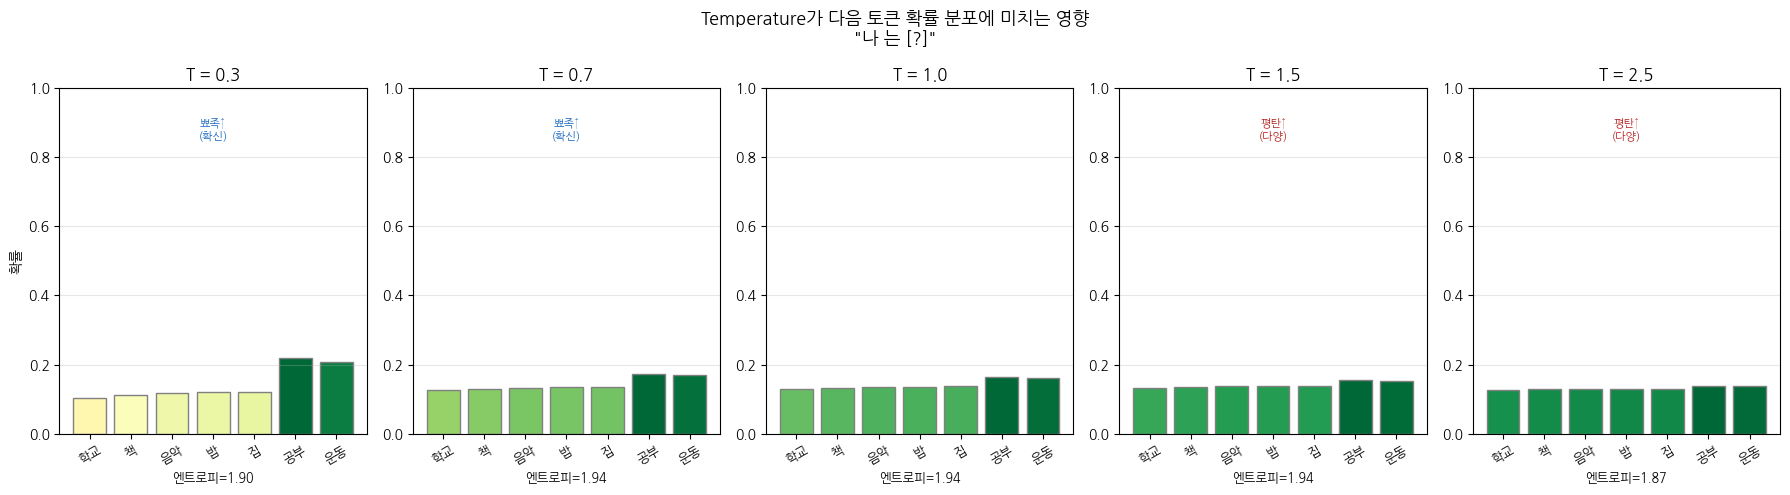

In [47]:
# Temperature가 확률 분포에 미치는 영향 시각화
lm.eval()
with torch.no_grad():
    # 나 는 -> 다음 토큰 확률
    x = torch.tensor([[BOS, V2I['나'], V2I['는']]]).to(device)
    logits, _ = lm(x)
    raw_logits = logits[0, -1].cpu()

temps = [0.3, 0.7, 1.0, 1.5, 2.5]
fig, axes = plt.subplots(1, len(temps), figsize=(18, 5), sharey=False)

# 의미있는 토큰만 표시
show_ids  = [V2I.get(w, UNK) for w in ['학교','책','음악','밥','집','공부','운동']]
show_words= ['학교','책','음악','밥','집','공부','운동']

for ax, T in zip(axes, temps):
    probs = F.softmax(raw_logits / T, dim=-1)
    vals  = [probs[i].item() for i in show_ids]
    colors= plt.cm.RdYlGn(np.array(vals) / max(vals))
    bars  = ax.bar(range(len(show_ids)), vals, color=colors, edgecolor='gray')
    ax.set_xticks(range(len(show_ids)))
    ax.set_xticklabels(show_words, rotation=30, fontsize=9)
    ax.set_title(f'T = {T}', fontweight='bold', fontsize=12)
    ax.set_ylabel('확률' if T == temps[0] else '')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    entropy = -sum(p*math.log(p+1e-10) for p in vals)
    ax.set_xlabel(f'엔트로피={entropy:.2f}', fontsize=9)
    if T < 1: ax.text(3, 0.85, '뾰족↑\n(확신)', ha='center', fontsize=8, color='#1565C0')
    elif T > 1: ax.text(3, 0.85, '평탄↑\n(다양)', ha='center', fontsize=8, color='#B71C1C')

plt.suptitle('Temperature가 다음 토큰 확률 분포에 미치는 영향\n"나 는 [?]"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('temperature_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ Top-k vs Top-p 차이 시각화

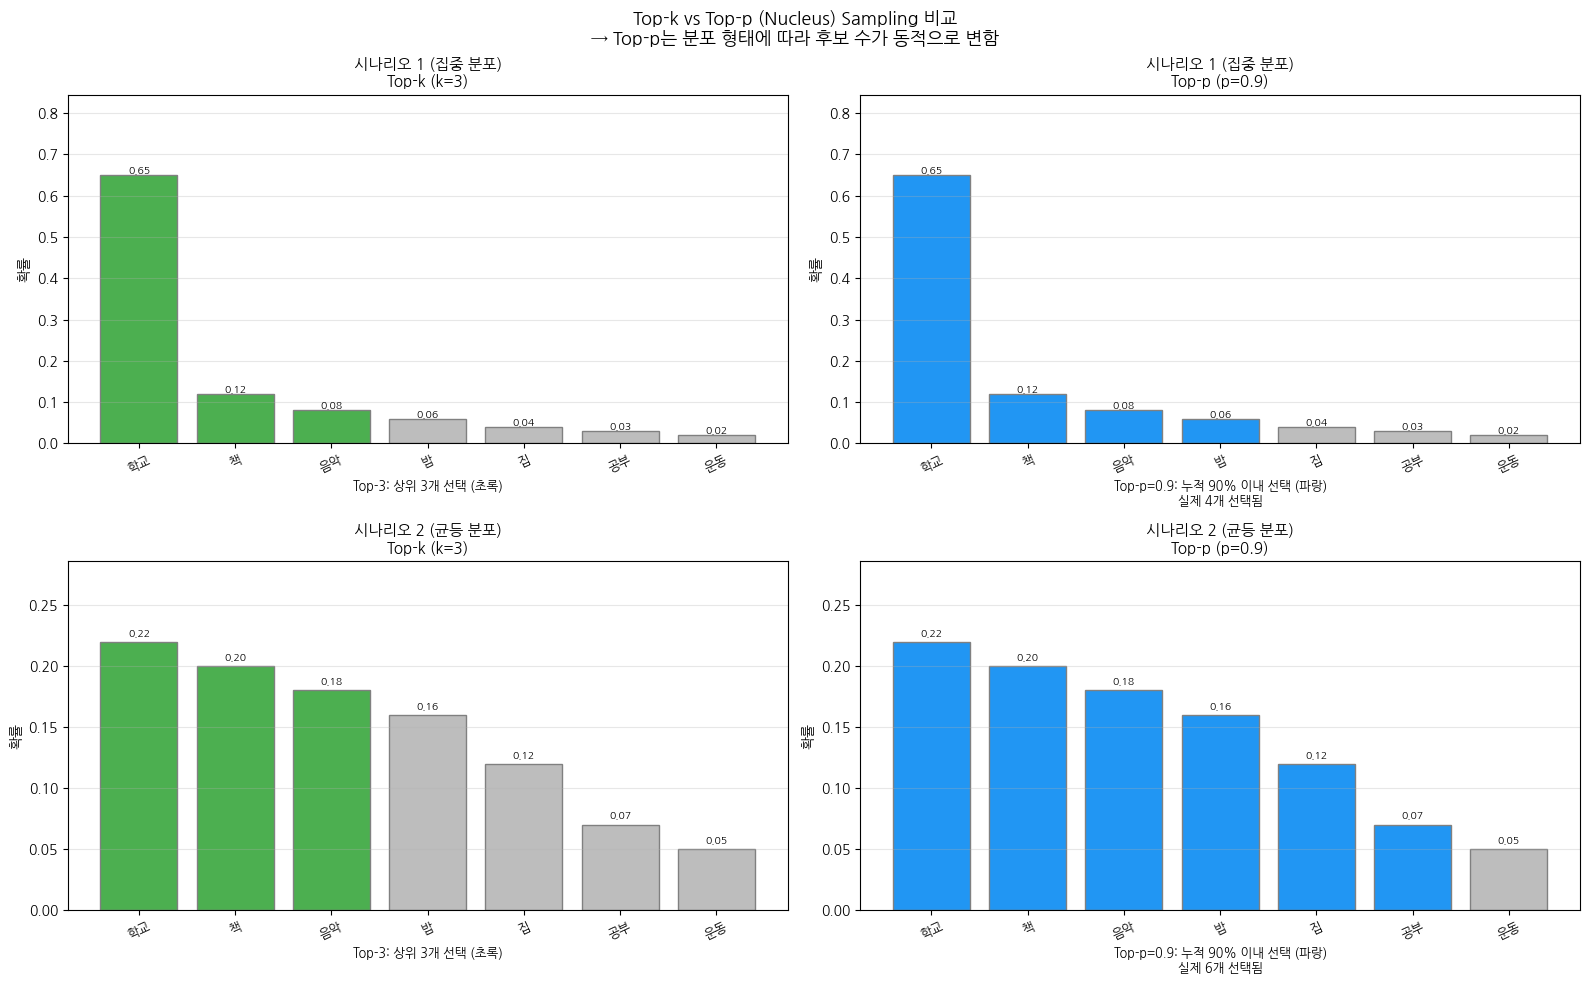

[핵심 차이 요약]
시나리오 1 (집중 분포):
  Top-k(3): 항상 3개 선택  — 저확률 단어도 강제 포함될 수 있음
  Top-p(0.9): ~2개 선택    — 자동으로 핵심 단어만 선택
시나리오 2 (균등 분포):
  Top-k(3): 여전히 3개     — 나머지 고확률 단어 배제
  Top-p(0.9): ~6개 선택    — 더 많은 후보 고려


In [48]:
# Top-k와 Top-p의 차이를 두 가지 분포로 비교
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def plot_sampling_method(ax, probs, words, method, param, title):
    ax.set_title(title, fontweight='bold', fontsize=11)
    colors = ['#BDBDBD'] * len(probs)

    if method == 'top_k':
        k = param
        sorted_idx = np.argsort(probs)[::-1]
        for i in sorted_idx[:k]: colors[i] = '#4CAF50'
        ax.set_xlabel(f'Top-{k}: 상위 {k}개 선택 (초록)', fontsize=9)

    elif method == 'top_p':
        p = param
        sorted_idx = np.argsort(probs)[::-1]
        cum = 0.0
        for i in sorted_idx:
            if cum < p:
                colors[i] = '#2196F3'
                cum += probs[i]
        ax.set_xlabel(f'Top-p={p}: 누적 {p*100:.0f}% 이내 선택 (파랑)\n실제 {sum(1 for c in colors if c=="#2196F3")}개 선택됨', fontsize=9)

    bars = ax.bar(range(len(probs)), probs, color=colors, edgecolor='gray')
    ax.set_xticks(range(len(probs)))
    ax.set_xticklabels(words, rotation=25, fontsize=9)
    ax.set_ylabel('확률')
    ax.set_ylim(0, max(probs) * 1.3)
    ax.grid(axis='y', alpha=0.3)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{p:.2f}', ha='center', fontsize=7.5)

# 두 가지 시나리오
# 시나리오 1: 한 단어가 압도적으로 높은 경우
words1 = ['학교','책','음악','밥','집','공부','운동']
probs1 = np.array([0.65, 0.12, 0.08, 0.06, 0.04, 0.03, 0.02])

# 시나리오 2: 여러 단어가 고르게 분포
probs2 = np.array([0.22, 0.20, 0.18, 0.16, 0.12, 0.07, 0.05])

plot_sampling_method(axes[0,0], probs1, words1, 'top_k', 3,
    '시나리오 1 (집중 분포)\nTop-k (k=3)')
plot_sampling_method(axes[0,1], probs1, words1, 'top_p', 0.9,
    '시나리오 1 (집중 분포)\nTop-p (p=0.9)')
plot_sampling_method(axes[1,0], probs2, words1, 'top_k', 3,
    '시나리오 2 (균등 분포)\nTop-k (k=3)')
plot_sampling_method(axes[1,1], probs2, words1, 'top_p', 0.9,
    '시나리오 2 (균등 분포)\nTop-p (p=0.9)')

plt.suptitle('Top-k vs Top-p (Nucleus) Sampling 비교\n'
             '→ Top-p는 분포 형태에 따라 후보 수가 동적으로 변함',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('topk_topp_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print('[핵심 차이 요약]')
print('시나리오 1 (집중 분포):')
print(f'  Top-k(3): 항상 3개 선택  — 저확률 단어도 강제 포함될 수 있음')
print(f'  Top-p(0.9): ~2개 선택    — 자동으로 핵심 단어만 선택')
print('시나리오 2 (균등 분포):')
print(f'  Top-k(3): 여전히 3개     — 나머지 고확률 단어 배제')
print(f'  Top-p(0.9): ~6개 선택    — 더 많은 후보 고려')

## 8️⃣ Beam Search 길이 페널티 분석

### 11.1) 간단한 Seq2Seq 모델 정의 및 학습 (번역 비교를 위한 준비)

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 토큰 정의
BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

class Vocab:
    def __init__(self, name):
        self.name = name
        self.word_to_index = {PAD_TOKEN: 0, UNK_TOKEN: 1, BOS_TOKEN: 2, EOS_TOKEN: 3}
        self.word_to_count = {}
        self.index_to_word = {0: PAD_TOKEN, 1: UNK_TOKEN, 2: BOS_TOKEN, 3: EOS_TOKEN}
        self.num_words = 4  # Count PAD, UNK, BOS, EOS

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word_to_index:
            self.word_to_index[word] = self.num_words
            self.word_to_count[word] = 1
            self.index_to_word[self.num_words] = word
            self.num_words += 1
        else:
            self.word_to_count[word] += 1

    def encode(self, sentence):
        return [self.word_to_index.get(word, self.word_to_index[UNK_TOKEN])
                for word in sentence.split(' ')]

    def decode(self, indices):
        return ' '.join([self.index_to_word[idx] for idx in indices if idx not in [self.word_to_index[BOS_TOKEN], self.word_to_index[EOS_TOKEN], self.word_to_index[PAD_TOKEN]]])

In [50]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers=1, dropout_rate=0.5):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, dropout=dropout_rate, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, (hidden, cell)

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers=1, dropout_rate=0.5):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, dropout=dropout_rate, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(1) # [batch_size, 1]
        embedded = self.dropout(self.embedding(input))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1)) # [batch_size, output_dim]
        return prediction, hidden, cell

    def forward_step(self, input_token, hidden):
        # For BeamSearchDecoder, assumes input_token is already token ID and hidden is (h, c)
        # Input token shape: [batch_size, 1]
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))
        output, (h, c) = self.lstm(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, (h, c)


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1

        return outputs

    def translate(self, sentence, src_vocab, trg_vocab, max_len=15):
        self.eval()
        with torch.no_grad():
            src_indexes = [src_vocab.word_to_index[BOS_TOKEN]] + [src_vocab.word_to_index.get(word, src_vocab.word_to_index[UNK_TOKEN]) for word in sentence.split(' ')] + [src_vocab.word_to_index[EOS_TOKEN]]
            src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(self.device)

            encoder_outputs, (hidden, cell) = self.encoder(src_tensor)

            trg_indexes = [trg_vocab.word_to_index[BOS_TOKEN]]
            input = torch.LongTensor([trg_vocab.word_to_index[BOS_TOKEN]]).to(self.device)

            for t in range(max_len):
                output, hidden, cell = self.decoder(input, hidden, cell)
                pred_token = output.argmax(1).item()
                trg_indexes.append(pred_token)
                if pred_token == trg_vocab.word_to_index[EOS_TOKEN]:
                    break
                input = torch.LongTensor([pred_token]).to(self.device)

            translated_sentence = [trg_vocab.index_to_word[idx] for idx in trg_indexes if idx not in [trg_vocab.word_to_index[BOS_TOKEN], trg_vocab.word_to_index[EOS_TOKEN], trg_vocab.word_to_index[PAD_TOKEN]]]
            return ' '.join(translated_sentence)


In [51]:
# 학습 데이터 (간단한 예시)
TRANSLATION_PAIRS = [
    ("hello", "안녕"),
    ("how are you", "잘 지내?"),
    ("i am fine", "나는 잘 지내"),
    ("thank you", "고마워"),
    ("goodbye", "안녕히 계세요")
]

# Vocab 초기화
src_vocab = Vocab("src")
trg_vocab = Vocab("trg")

for src, trg in TRANSLATION_PAIRS:
    src_vocab.add_sentence(src)
    trg_vocab.add_sentence(trg)

# 데이터 준비 함수
def prepare_data(pairs, src_vocab, trg_vocab, device):
    src_tensors = []
    trg_tensors = []
    for src, trg in pairs:
        src_indexed = [src_vocab.word_to_index[BOS_TOKEN]] + src_vocab.encode(src) + [src_vocab.word_to_index[EOS_TOKEN]]
        trg_indexed = [trg_vocab.word_to_index[BOS_TOKEN]] + trg_vocab.encode(trg) + [trg_vocab.word_to_index[EOS_TOKEN]]
        src_tensors.append(torch.tensor(src_indexed, dtype=torch.long))
        trg_tensors.append(torch.tensor(trg_indexed, dtype=torch.long))

    # 패딩
    src_padded = nn.utils.rnn.pad_sequence(src_tensors, batch_first=True, padding_value=src_vocab.word_to_index[PAD_TOKEN])
    trg_padded = nn.utils.rnn.pad_sequence(trg_tensors, batch_first=True, padding_value=trg_vocab.word_to_index[PAD_TOKEN])

    return src_padded.to(device), trg_padded.to(device)

In [52]:
# 모델 학습
INPUT_DIM = src_vocab.num_words
OUTPUT_DIM = trg_vocab.num_words
ENC_EMB_DIM = 32
DEC_EMB_DIM = 32
HID_DIM = 64
N_LAYERS = 1
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

model = Seq2Seq(enc, dec, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.word_to_index[PAD_TOKEN])

print('Seq2Seq 모델 학습 중...')

for epoch in range(1, 101):
    model.train()
    src_data, trg_data = prepare_data(TRANSLATION_PAIRS, src_vocab, trg_vocab, device)

    optimizer.zero_grad()
    output = model(src_data, trg_data)

    # output은 <EOS>를 제외한 마지막 토큰까지 예측해야 하므로, trg_data의 마지막 토큰을 제외하고 비교
    output_dim = output.shape[-1]
    output = output[:, 1:].reshape(-1, output_dim)
    trg_data_ = trg_data[:, 1:].reshape(-1)

    loss = criterion(output, trg_data_)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f'  Epoch {epoch}: Loss = {loss.item():.4f}')
print('✅ Seq2Seq 모델 학습 완료')


Seq2Seq 모델 학습 중...
  Epoch 20: Loss = 0.5296
  Epoch 40: Loss = 0.0153
  Epoch 60: Loss = 0.0059
  Epoch 80: Loss = 0.0019
  Epoch 100: Loss = 0.0019
✅ Seq2Seq 모델 학습 완료


In [53]:
# 길이 페널티가 빔 서치 결과에 미치는 영향
print('[Beam Search 길이 페널티 비교]\n')
print('길이 페널티 공식: score(Y) = log_prob(Y) / len(Y)^α\n')

# 다양한 길이 페널티로 실험
alpha_results = {}
for alpha in [0.0, 0.3, 0.6, 1.0, 1.5]:
    result, score, beams = beam_search_decode(
        lm, beam_size=4, max_len=12,
        length_penalty=alpha, verbose=False
    )
    alpha_results[alpha] = ' '.join(result)
    print(f'  α={alpha:.1f}: "{" ".join(result)}"  (길이={len(result)})')

print('\n길이 페널티 효과:')
print('  α=0.0: 길이 무관 (짧은 시퀀스 선호 경향)')
print('  α=0.6: 적당한 페널티 (Google NMT 기본값)')
print('  α=1.0: 선형 페널티')
print('  α>1.0: 긴 시퀀스 강하게 선호')

# beam_size별 결과 품질 비교
print('\n[Beam Size 비교]\n')
for bsize in [1, 2, 3, 5, 10]:
    result, score, beams = beam_search_decode(
        lm, beam_size=bsize, max_len=10,
        length_penalty=0.6, verbose=False
    )
    label = '(= Greedy)' if bsize == 1 else ''
    print(f'  beam_size={bsize:>2}: "{" ".join(result)}"  score={score:.4f} {label}')

[Beam Search 길이 페널티 비교]

길이 페널티 공식: score(Y) = log_prob(Y) / len(Y)^α

  α=0.0: "나 는 공부 한다"  (길이=4)
  α=0.3: "나 는 공부 한다"  (길이=4)
  α=0.6: "나 는 집 에서 잔다"  (길이=5)
  α=1.0: "나 는 집 에서 잔다"  (길이=5)
  α=1.5: "나 는 집 에서 잔다"  (길이=5)

길이 페널티 효과:
  α=0.0: 길이 무관 (짧은 시퀀스 선호 경향)
  α=0.6: 적당한 페널티 (Google NMT 기본값)
  α=1.0: 선형 페널티
  α>1.0: 긴 시퀀스 강하게 선호

[Beam Size 비교]

  beam_size= 1: "나 는 공부 한다"  score=-1.8104 (= Greedy)
  beam_size= 2: "나 는 공부 한다"  score=-1.8104 
  beam_size= 3: "나 는 집 에서 잔다"  score=-1.9866 
  beam_size= 5: "나 는 집 에서 잔다"  score=-1.9866 
  beam_size=10: "나 는 집 에서 잔다"  score=-1.9866 


## 9️⃣ 모든 Decoding 방법 종합 비교

             방법 |      다양성 |     평균 길이 | 예시
         Greedy |    0.050 |      4.00 | 나 는 공부 한다
         Beam-2 |    0.050 |      4.00 | 나 는 공부 한다
         Beam-5 |    0.050 |      5.00 | 나 는 집 에서 잔다
       Temp-0.7 |    0.300 |      4.65 | 나 는 학교 에 간다
       Temp-1.5 |    0.300 |      4.65 | 나 는 운동 한다
       Top-k(3) |    0.150 |      4.25 | 나 는 운동 한다
       Top-k(8) |    0.300 |      4.55 | 나 는 공부 한다
     Top-p(0.7) |    0.350 |      4.60 | 나 는 책 읽 는다
    Top-p(0.95) |    0.350 |      4.50 | 나 는 운동 한다


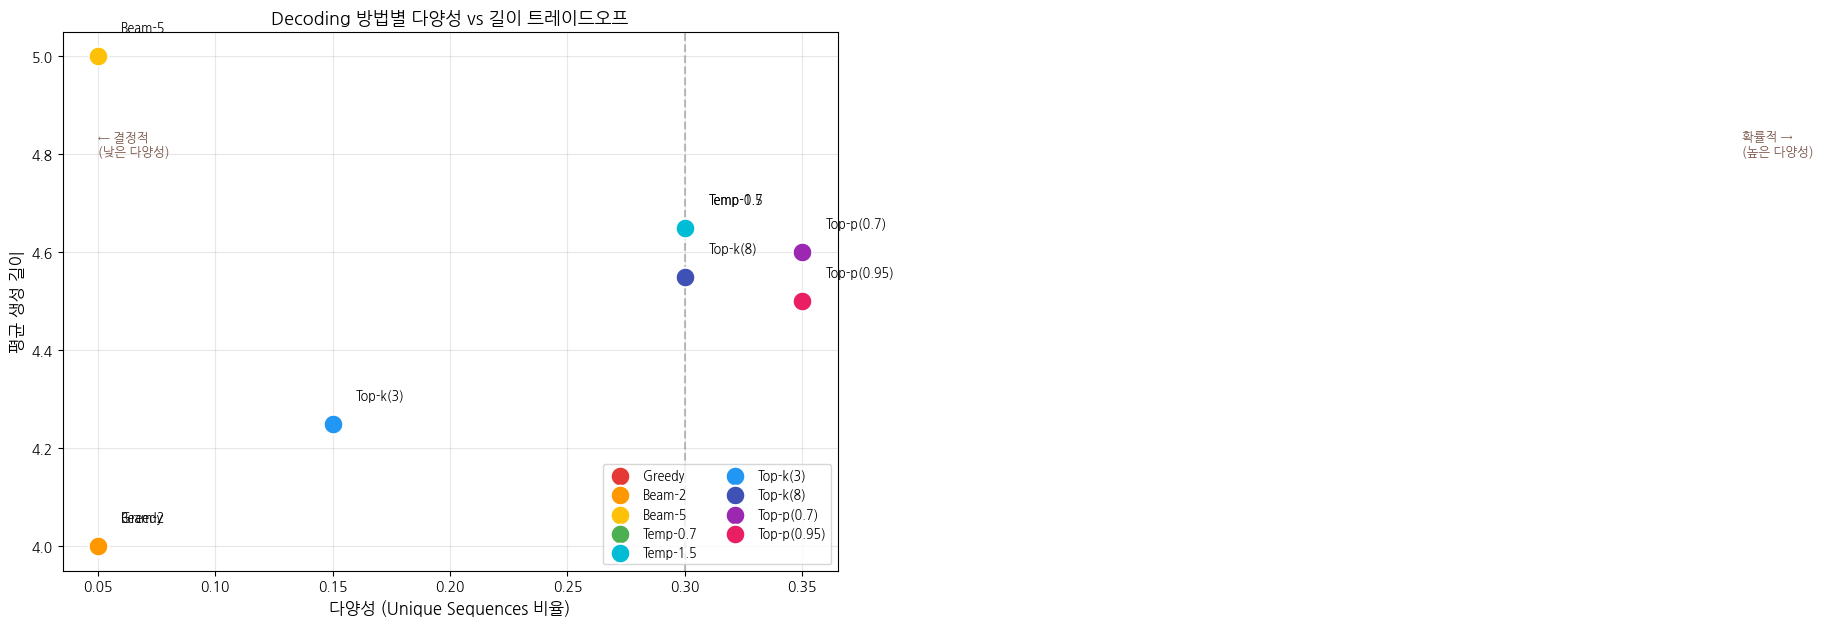

In [54]:
# 다양성 vs 품질 트레이드오프 시각화
n_repeat = 20

def diversity_score(samples):
    """생성된 시퀀스들의 다양성 (unique 비율)"""
    return len(set(samples)) / len(samples)

def avg_length(samples):
    return np.mean([len(s.split()) for s in samples])

methods = {
    'Greedy':           lambda: [' '.join(greedy_decode(lm, verbose=False)[0]) for _ in range(n_repeat)],
    'Beam-2':           lambda: [' '.join(beam_search_decode(lm,beam_size=2,verbose=False)[0]) for _ in range(n_repeat)],
    'Beam-5':           lambda: [' '.join(beam_search_decode(lm,beam_size=5,verbose=False)[0]) for _ in range(n_repeat)],
    'Temp-0.7':         lambda: sampling_decode(lm,'temperature',temperature=0.7, n_samples=n_repeat),
    'Temp-1.5':         lambda: sampling_decode(lm,'temperature',temperature=1.5, n_samples=n_repeat),
    'Top-k(3)':         lambda: sampling_decode(lm,'top_k',top_k=3,  n_samples=n_repeat),
    'Top-k(8)':         lambda: sampling_decode(lm,'top_k',top_k=8,  n_samples=n_repeat),
    'Top-p(0.7)':       lambda: sampling_decode(lm,'top_p',top_p=0.7, n_samples=n_repeat),
    'Top-p(0.95)':      lambda: sampling_decode(lm,'top_p',top_p=0.95, n_samples=n_repeat),
}

results_summary = {}
for name, fn in methods.items():
    samples = fn()
    results_summary[name] = {
        'diversity': diversity_score(samples),
        'avg_len':   avg_length(samples),
        'samples':   samples[:3],
    }

print(f"{'방법':>15} | {'다양성':>8} | {'평균 길이':>9} | 예시")
print('=' * 70)
for name, info in results_summary.items():
    ex = info['samples'][0]
    print(f"{name:>15} | {info['diversity']:>8.3f} | {info['avg_len']:>9.2f} | {ex}")

# 다양성 vs 평균 길이 산점도
fig, ax = plt.subplots(figsize=(10, 7))
colors_map = {'Greedy':'#E53935','Beam-2':'#FF9800','Beam-5':'#FFC107',
              'Temp-0.7':'#4CAF50','Temp-1.5':'#00BCD4',
              'Top-k(3)':'#2196F3','Top-k(8)':'#3F51B5',
              'Top-p(0.7)':'#9C27B0','Top-p(0.95)':'#E91E63'}

for name, info in results_summary.items():
    ax.scatter(info['diversity'], info['avg_len'],
               s=200, c=colors_map[name],
               label=name, zorder=3, edgecolors='white', linewidths=1.5)
    ax.annotate(name, (info['diversity']+0.01, info['avg_len']+0.05), fontsize=9)

ax.set_xlabel('다양성 (Unique Sequences 비율)', fontsize=12)
ax.set_ylabel('평균 생성 길이', fontsize=12)
ax.set_title('Decoding 방법별 다양성 vs 길이 트레이드오프', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.grid(alpha=0.3)

ax.axvline(0.3, color='gray', linestyle='--', alpha=0.5)
ax.text(0.05, ax.get_ylim()[1]*0.95, '← 결정적\n(낮은 다양성)', fontsize=9, color='#795548')
ax.text(0.75, ax.get_ylim()[1]*0.95, '확률적 →\n(높은 다양성)', fontsize=9, color='#795548')

plt.tight_layout()
plt.savefig('decoding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔟 태스크별 최적 Decoding 전략 가이드

In [55]:
DECODING_GUIDE = """
╔═══════════════════════════════════════════════════════════════════╗
║          Decoding 기법 종합 가이드 & 태스크별 추천 전략            ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  [Greedy Decoding]                                                ║
║    알고리즘: next_token = argmax(P(w|context))                    ║
║    복잡도:  O(V × T)  ← 가장 빠름                                ║
║    장점:    단순, 빠름, 일관된 결과                                ║
║    단점:    지역 최적해 (locally optimal, globally suboptimal)    ║
║    추천:    실시간 응답, 속도 중요한 태스크                        ║
║                                                                   ║
║  [Beam Search]                                                    ║
║    알고리즘: 상위 k개 후보 동시 유지 + 길이 페널티                 ║
║    복잡도:  O(k × V × T)                                         ║
║    장점:    Greedy보다 전역적으로 더 좋은 시퀀스 탐색              ║
║    단점:    느림, 다양성 부족, beam collapse 위험                  ║
║    권장 설정: beam_size=4~8, length_penalty=0.6 (Google NMT)      ║
║    추천:    기계 번역, 텍스트 요약 (품질 중요)                     ║
║                                                                   ║
║  [Top-k Sampling]                                                 ║
║    알고리즘: 상위 k개 토큰에서 확률적 선택                         ║
║    장점:    다양성 확보, 창의적 출력                               ║
║    단점:    k 값에 민감, 분포 형태 무관하게 고정 k                 ║
║    권장 설정: k=40~50 (GPT-2 기본값)                              ║
║    추천:    창의적 글쓰기, 스토리 생성                              ║
║                                                                   ║
║  [Top-p (Nucleus) Sampling]                                       ║
║    알고리즘: 누적 확률 p 이내 토큰에서 샘플링 (동적 k)             ║
║    장점:    분포에 적응적, Top-k보다 균형잡힌 다양성               ║
║    권장 설정: p=0.9~0.95                                          ║
║    추천:    대화 시스템, 일반적인 텍스트 생성                      ║
║                                                                   ║
║  ━━━ 태스크별 추천 전략 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ║
║                                                                   ║
║  번역/요약     → Beam Search (beam=4, alpha=0.6)                  ║
║  코드 생성     → Greedy or Beam Search (정확성 중요)              ║
║  창의적 글쓰기 → Top-p (p=0.9) + Temperature (T=0.8~1.2)         ║
║  대화 시스템   → Top-p (p=0.9) or Top-k (k=50)                   ║
║  다양한 답변   → Temperature (T>1.0) + Top-p                     ║
║  질문 답변     → Greedy or low Temperature (T<1.0)                ║
╚═══════════════════════════════════════════════════════════════════╝
"""
print(DECODING_GUIDE)


╔═══════════════════════════════════════════════════════════════════╗
║          Decoding 기법 종합 가이드 & 태스크별 추천 전략            ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  [Greedy Decoding]                                                ║
║    알고리즘: next_token = argmax(P(w|context))                    ║
║    복잡도:  O(V × T)  ← 가장 빠름                                ║
║    장점:    단순, 빠름, 일관된 결과                                ║
║    단점:    지역 최적해 (locally optimal, globally suboptimal)    ║
║    추천:    실시간 응답, 속도 중요한 태스크                        ║
║                                                                   ║
║  [Beam Search]                                                    ║
║    알고리즘: 상위 k개 후보 동시 유지 + 길이 페널티                 ║
║    복잡도:  O(k × V × T)                                         ║
║    장점:    Greedy보다 전역적으로 더 좋은 시퀀스 탐색              ║
║    단점:    느림, 다양성 부족, beam collapse 위험   

## 1️⃣1️⃣ 실전: Seq2Seq 번역 모델에 Beam Search 적용

In [58]:
# ── 이전 노트북의 Seq2Seq + 이번 노트북의 Beam Search 통합 ──
# 간단한 Seq2Seq 번역 모델에 Beam Search를 직접 적용

class BeamSearchDecoder:
    """
    범용 Beam Search 디코더
    어떤 Seq2Seq 모델에도 적용 가능한 인터페이스
    """
    def __init__(self, model, beam_size=4, max_len=30,
                  length_penalty=0.6, temperature=1.0):
        self.model          = model
        self.beam_size      = beam_size
        self.max_len        = max_len
        self.length_penalty = length_penalty
        self.temperature    = temperature

    def decode(self, encoder_outputs, encoder_hidden,
                bos_id, eos_id, vocab, device='cpu'):
        """
        Beam Search로 번역 시퀀스 생성
        반환: (최고 번역문, 상위 k개 후보 리스트)
        """
        # (log_prob, seq, hidden, is_done)
        beams = [(0.0, [bos_id], encoder_hidden, False)]
        completed_beams = []

        for step in range(self.max_len):
            all_candidates = []

            for lp, seq, hidden, done in beams:
                if done:
                    completed_beams.append((lp, seq))
                    continue

                last_tok = torch.tensor([seq[-1]], device=device)
                with torch.no_grad():
                    logit, new_hidden = self.model.decoder.forward_step(
                        last_tok, hidden)

                log_probs = F.log_softmax(logit.squeeze(0) / self.temperature, dim=-1)
                topk_lp, topk_ids = log_probs.topk(self.beam_size)

                for new_lp, tid in zip(topk_lp, topk_ids):
                    tid = tid.item()
                    new_seq  = seq + [tid]
                    new_done = (tid == eos_id)
                    all_candidates.append((
                        lp + new_lp.item(), new_seq, new_hidden, new_done
                    ))

            if not all_candidates:
                break

            # 길이 페널티 정렬
            def score(item):
                lp, seq, _, _ = item
                return lp / max(len(seq)-1, 1) ** self.length_penalty

            all_candidates.sort(key=score, reverse=True)
            beams = [c for c in all_candidates[:self.beam_size] if not c[3]]
            completed_beams += [(c[0], c[1]) for c in all_candidates[:self.beam_size] if c[3]]

            if not beams:
                break

        completed_beams += [(b[0], b[1]) for b in beams]
        completed_beams.sort(key=lambda x: x[0]/max(len(x[1])-1,1)**self.length_penalty, reverse=True)

        top_results = []
        for lp, seq in completed_beams[:self.beam_size]:
            words = [vocab.index_to_word[t] for t in seq[1:]
                     if t not in (bos_id, eos_id, 0)]
            top_results.append((' '.join(words), lp))

        return top_results[0][0] if top_results else '', top_results


print('[Beam Search vs Greedy — 번역 비교]\n')
print(f"{'원문':>22} | {'Greedy':>18} | {'Beam(k=4)':>18} | {'정답':>18}")
print('=' * 85)

# 이전 노트북 모델 재사용 (없으면 새로 학습)
try:
    from copy import deepcopy
    # 간단한 재학습
    en_vocab = src_vocab
    ko_vocab = trg_vocab
    test_pairs = TRANSLATION_PAIRS[:5]
    for src_sent, trg_sent in test_pairs:
        greedy_result = model.translate(src_sent, en_vocab, ko_vocab)
        # Beam Search
        # encoder_outputs, (hidden, cell) = model.encoder(src_tensor) from Seq2Seq.translate
        # Need to re-create src_tensor to get encoder outputs and hidden state for the BeamSearchDecoder
        src_indexes = [en_vocab.word_to_index[BOS_TOKEN]] + [en_vocab.word_to_index.get(word, en_vocab.word_to_index[UNK_TOKEN]) for word in src_sent.split(' ')] + [en_vocab.word_to_index[EOS_TOKEN]]
        src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)

        enc_outs, enc_hidden = model.encoder(src_tensor)

        bs_decoder = BeamSearchDecoder(model, beam_size=4, max_len=15,
                                         length_penalty=0.6)
        beam_result, candidates = bs_decoder.decode(
            enc_outs, enc_hidden,
            bos_id=ko_vocab.word_to_index[BOS_TOKEN],
            eos_id=ko_vocab.word_to_index[EOS_TOKEN],
            vocab=ko_vocab, device=device
        )
        print(f"{src_sent:>22} | {greedy_result:>18} | {beam_result:>18} | {trg_sent:>18}")
except Exception as e:
    print(f'(이전 노트북 모델 없음 — 위 셀들을 먼저 실행하세요)')
    print(f'오류: {e}')

[Beam Search vs Greedy — 번역 비교]

                    원문 |             Greedy |          Beam(k=4) |                 정답
                 hello |              잘 지내? |              잘 지내? |                 안녕
           how are you |              잘 지내? |              잘 지내? |              잘 지내?
             i am fine |            나는 잘 지내 |            나는 잘 지내 |            나는 잘 지내
             thank you |              잘 지내? |              잘 지내? |                고마워
               goodbye |            안녕히 계세요 |            안녕히 계세요 |            안녕히 계세요


## 1️⃣2️⃣ Greedy vs Beam Search 수렴 경로 시뮬레이션

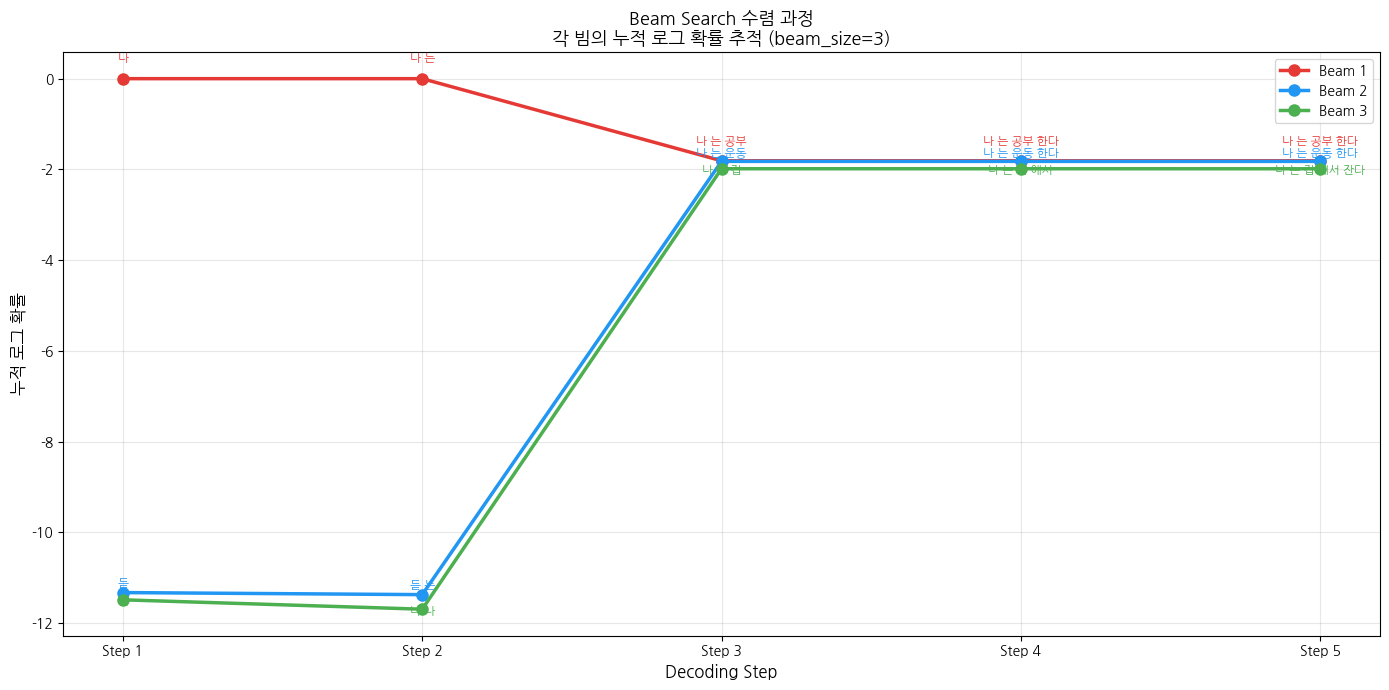

In [57]:
# 수렴 과정 시각화 (누적 로그 확률 추적)
lm.eval()

def trace_beam_steps(model, beam_size=3, max_len=6):
    """Beam Search의 각 스텝에서 빔 확장 과정 추적"""
    beams = [(0.0, [BOS], None)]
    steps_log = []

    for step in range(max_len):
        all_cands = []
        with torch.no_grad():
            for lp, seq, hidden in beams:
                if seq[-1] == EOS: continue
                probs, new_h = model.get_next_probs(seq[-1], hidden)
                topk = probs.topk(beam_size)
                for p, tid in zip(topk.values, topk.indices):
                    all_cands.append((
                        lp + math.log(p.item()+1e-10),
                        seq + [tid.item()], new_h
                    ))

        all_cands.sort(key=lambda x: x[0], reverse=True)
        beams = all_cands[:beam_size]
        step_info = [
            (' '.join(I2V.get(t,'?') for t in s[1:] if t not in (BOS,EOS)), lp)
            for lp, s, _ in beams
        ]
        steps_log.append(step_info)

    return steps_log


steps = trace_beam_steps(lm, beam_size=3, max_len=5)

fig, ax = plt.subplots(figsize=(14, 7))
colors_beam = ['#E53935', '#2196F3', '#4CAF50']

for beam_idx in range(3):
    beam_scores = []
    beam_labels = []
    for step_info in steps:
        if beam_idx < len(step_info):
            beam_scores.append(step_info[beam_idx][1])
            beam_labels.append(step_info[beam_idx][0])

    x_pos = range(1, len(beam_scores)+1)
    ax.plot(x_pos, beam_scores,
            color=colors_beam[beam_idx], lw=2.5, marker='o', ms=8,
            label=f'Beam {beam_idx+1}')

    for x, y, label in zip(x_pos, beam_scores, beam_labels):
        ax.annotate(label, (x, y), textcoords='offset points',
                    xytext=(0, 12 - beam_idx*8), ha='center', fontsize=8.5,
                    color=colors_beam[beam_idx])

ax.set_xlabel('Decoding Step', fontsize=12)
ax.set_ylabel('누적 로그 확률', fontsize=12)
ax.set_title('Beam Search 수렴 과정\n각 빔의 누적 로그 확률 추적 (beam_size=3)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.set_xticks(range(1, len(steps)+1))
ax.set_xticklabels([f'Step {i}' for i in range(1, len(steps)+1)])

plt.tight_layout()
plt.savefig('beam_convergence.png', dpi=150, bbox_inches='tight')
plt.show()